### dyngen绘制指标
（毫无复用性的代码hh）

以下代码只需运行一次

In [6]:
import scanpy as sc
adata_path = '/HDD1/xueweizhi/spvelo_data/simulate/simulate_dyngen/standard/general/dataset.h5ad'
adata = sc.read(adata_path)
cate_list = adata.obs['progress'].cat.categories.tolist()
cate_list

/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


['sA->sB', 'sB->sBmid', 'sBmid->sC', 'sBmid->sD', 'sC->sEndC', 'sD->sEndD']

In [7]:
import pickle as pkl

clusters_path = '../clusters/dyngen.pkl'
# dump clusters
with open(clusters_path, 'wb') as f:
    pkl.dump(cate_list, f)

共用的代码段

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [9]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = '../clusters/dyngen.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [10]:
dataset = 'simulate/dyngen'
datas = ['general/dataset', 'general/dataset_2d', 'general_0.1/dataset', 'general_0.1/dataset_2d']

In [11]:
import os

In [12]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo(avg)": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt(vj)": "#cd8c95"
}

**cbdir**: coord和umap分别画

In [15]:
metric_name = 'cbdir'
bases = ['coord', 'umap']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']

for data in datas:
    for basis in bases:
        results = {}
        for cluster_edge in cluster_edges: 
            edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
            result = {}
            for model in models:
                model_name = model if model != 'scvelo' else 'scvelo_dynamical'
                # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
                metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
                with open(metric_file, 'rb') as f:
                    metric = pkl.load(f)
                if edge in metric.keys():
                    result[model] = metric[edge]
                if model == 'stt':
                    # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
                    stt_metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_vj.pkl'
                    with open(stt_metric_file, 'rb') as f:
                        stt_metric = pkl.load(f)
                    if edge in stt_metric.keys():
                        result['stt(vj)'] = stt_metric[edge]
            results[edge] = result
        
        save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
        os.makedirs(save_dir, exist_ok=True)

        for key, value in results.items():
            df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
            plt.figure(figsize=(8, 6))
            sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
            plt.ylim(-1.6, 1.6) # remember to change this
            plt.title(key)
            plt.savefig(f'{save_dir}/{metric_name}_{basis}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
            plt.show()

**k-cbdir**: coord和umap分别画

In [16]:
import re
import ast

In [ ]:
k = 5
metric_name = 'gen_cbdir_edge'
bases = ['coord', 'umap']
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
for data in datas:
    for basis in bases:
        results = {}
        for cluster_edge in cluster_edges:
            edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
            result = {'k': range(1, k+1)}
            for model in models: 
                model_name = model if model != 'scvelo' else 'scvelo_dynamical'
                # metric_file = f'../logs/{data}/{model}/metric_{basis}_redo.csv'
                metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}_redo.csv'
                if not os.path.exists(metric_file):
                    metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}.csv'
                metric = pd.read_csv(metric_file)
                metric.set_index('Unnamed: 0', inplace=True)
                idx_name = f'{metric_name}_{model_name}_velocity_{edge}'
                if idx_name in metric.index:
                    cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
                    if 'nan' not in cbdir:
                        cbdir = re.sub(r'\s+', ', ', cbdir)
                        cbdir = ast.literal_eval(cbdir)
                        result[model] = cbdir
                if model == 'stt': 
                    stt_idx_name = f'{metric_name}_vj_{edge}'
                    if stt_idx_name in metric.index:
                        cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                        if 'nan' not in cbdir:
                            cbdir = re.sub(r'\s+', ', ', cbdir)
                            cbdir = ast.literal_eval(cbdir)
                            result['stt(vj)'] = cbdir
            results[edge] = result

        save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
        os.makedirs(save_dir, exist_ok=True)

        for key, value in results.items():
            df = pd.DataFrame(value).melt(id_vars='k', var_name='model', value_name=metric_name)
            plt.figure(figsize=(8, 6))
            sns.lineplot(data=df, x='k', y=metric_name, hue='model', palette=model_colors)
            plt.ylim(-0.8, 1) # remember to change this
            plt.xticks(range(1, k+1))
            plt.title(key)
            plt.savefig(f'{save_dir}/{metric_name}_{basis}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
            plt.show()

**iccoh**: 不分basis

In [ ]:
metric_name = 'inner_cluster_coh'
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']

for data in datas:
    results = {}
    for cluster in clusters:
        result = {}
        for model in models:
            model_name = model if model != 'scvelo' else 'scvelo_dynamical'
            # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
            metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pkl.load(f)
            result[model] = metric[cluster]
            if model == 'stt':
                # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
                stt_metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    stt_metric = pkl.load(f)
                result['stt(vj)'] = stt_metric[cluster]
        results[cluster] = result
    
    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)

    for key, value in results.items():
        df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
        plt.figure(figsize=(8, 6))
        sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
        plt.ylim(0, 1.1) # remember to change this
        plt.title(key)
        plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
        plt.show()

**t-score**: 不分basis没有stt

In [ ]:
metric_name = 'time_score_edge'
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']

for data in datas:
    results = {}
    for cluster_edge in cluster_edges:
        edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
        result = {}
        for model in models:
            # metric_file = f'../logs/{data}/{model}/metric_{basis}_redo.csv'
            metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}_redo.csv'
            if not os.path.exists(metric_file):
                metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}.csv'
            metric = pd.read_csv(metric_file)
            metric.set_index('Unnamed: 0', inplace=True)
            idx_name = f'{metric_name}_pred_t_norm_{edge}'
            if idx_name in metric.index:
                t_score = metric.loc[metric.index == idx_name, '0'].values[0]
                t_score = float(t_score)
                result[model] = t_score
            if model == 'scvelo':
                scv_idx_name = f'{metric_name}_fit_t_norm_{edge}'
                if scv_idx_name in metric.index:
                    t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
                    t_score = float(t_score)
                    result['scvelo(avg)'] = t_score
        results[edge] = result

    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)

    for key, value in results.items():
        df = pd.DataFrame(list(value.items()), columns=['model', metric_name])
        plt.figure(figsize=(8, 6))
        sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
        plt.ylim(0, 1)
        plt.title(key)
        plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
        plt.show()

**spatial time consistency**
不分basis没有stt

In [ ]:
metric_name = 'spatial_time_consist'
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']
for data in datas:
    result = {}
    for model in models:
        metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'../logs/{model}/{dataset}/{data}/metric_{basis}.csv'
        metric = pd.read_csv(metric_file)
        metric.set_index('Unnamed: 0', inplace=True)
        idx_name = f'{metric_name}_pred_t_norm'
        t_score = metric.loc[metric.index == idx_name, '0'].values[0]
        t_score = float(t_score)
        result[model] = t_score
        if model == 'scvelo':
            scv_idx_name = f'{metric_name}_fit_t_norm'
            t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
            t_score = float(t_score)
            result['scvelo(avg)'] = t_score
    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)
    df = pd.DataFrame(list(result.items()), columns=['model', metric_name])
    plt.figure(figsize=(8, 6))
    sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
    plt.ylim(0, 1)
    plt.savefig(f'{save_dir}/{metric_name}.svg')
    plt.show()

**velocity consistency** (pca neigh.) & **spatial velocity consistency**
不分basis

In [25]:
import numpy as np

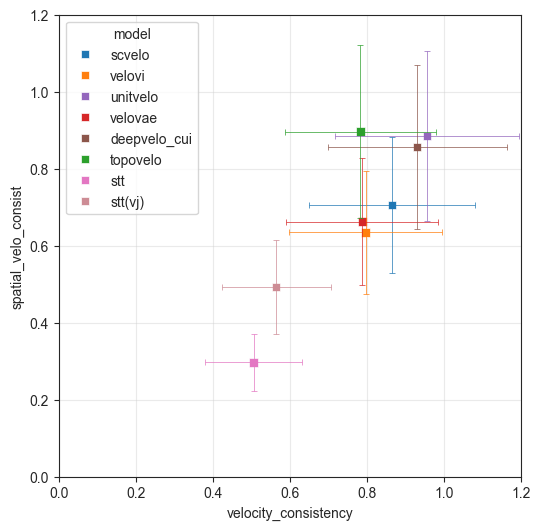

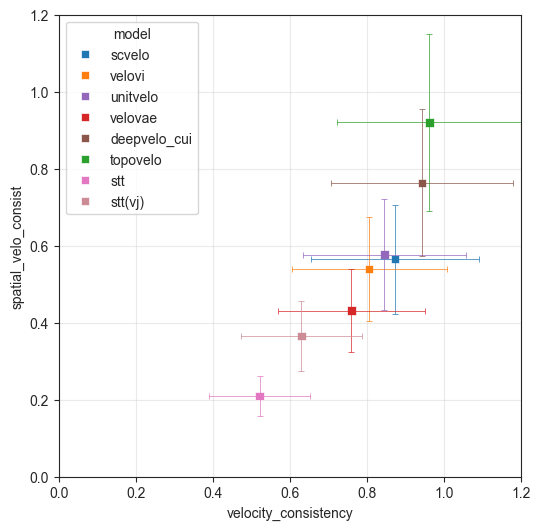

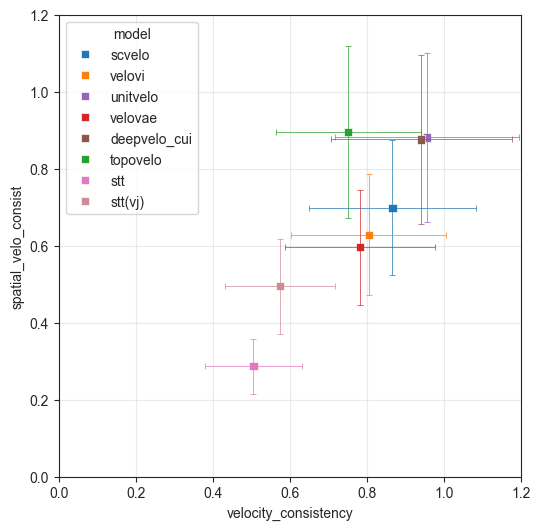

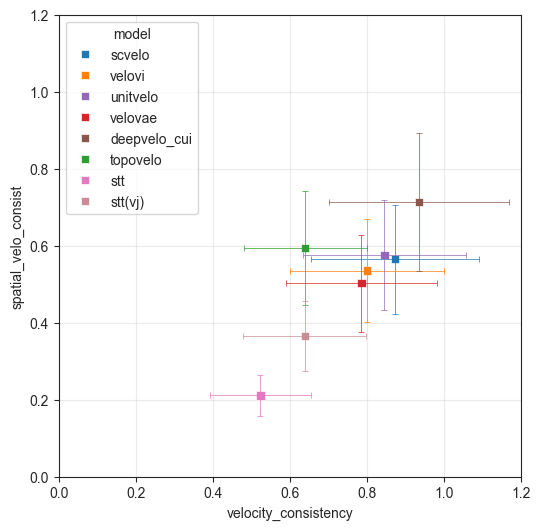

In [27]:
metric_names = ('velocity_consistency', 'spatial_velo_consist')
basis = 'coord' # 是什么不重要
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
for data in datas:
    results = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        result = {}
        for metric_name in metric_names:
            metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pd.read_pickle(f)
            result[metric_name] = metric
        results[model] = result
        if model == 'stt':
            result = {}
            for metric_name in metric_names:
                stt_metric_file = f'../logs/{model}/{dataset}/{data}/{metric_name}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    metric = pd.read_pickle(f)
                result[metric_name] = metric
            results['stt(vj)'] = result
    save_dir = f'../results/results_0128/{dataset.replace("simulate/", "")}/{data.replace("/", "_")}/metrics'
    os.makedirs(save_dir, exist_ok=True)

    import numpy as np
    keys = []
    velocity_consistency_means = []
    spatial_velo_consist_means = []
    velocity_consistency_stds = []
    spatial_velo_consist_stds = []
    for key, value in results.items():
        keys.append(key)
        velocity_consistency_means.append(np.mean(value['velocity_consistency']))
        spatial_velo_consist_means.append(np.mean(value['spatial_velo_consist']))
        velocity_consistency_stds.append(np.mean(value['velocity_consistency']))
        spatial_velo_consist_stds.append(np.mean(value['spatial_velo_consist']))
    df = pd.DataFrame({'model': keys, 'velocity_consistency': velocity_consistency_means, 'spatial_velo_consist': spatial_velo_consist_means})
    plt.figure(figsize=(8, 6))
    plt.xlim(0, 1.2)
    plt.ylim(0, 1.2)
    plt.gca().set_aspect('equal')
    sns.scatterplot(data=df, x='velocity_consistency', y='spatial_velo_consist', hue='model', palette=model_colors, marker='s')
    for i in range(df.shape[0]):
        plt.errorbar(df['velocity_consistency'][i], df['spatial_velo_consist'][i], xerr=0.25*velocity_consistency_stds[i], yerr=0.25*spatial_velo_consist_stds[i], fmt='none', color=model_colors[df['model'][i]], 
                    capsize=2, capthick=0.5, elinewidth=0.5)
    plt.grid(alpha=0.4)
    plt.savefig(f'{save_dir}/velocity_consistency_vs_spatial_velo_consist.svg')
    plt.show()
